In [68]:
#استدعاء المكتبات
import pandas as pd
import numpy as np
import re
import json
import random
import tkinter as tk
from tkinter import scrolledtext
from sentence_transformers import SentenceTransformer, util
import sklearn 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ploto\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ploto\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ploto\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [69]:
#قراءة ملف JSON
with open("intents.json", "r", encoding="utf-8") as f:
    json_data = json.load(f)

In [70]:
###تحويل ملف JSON 
# الى DataFrame
# في pandas
#على شكل جدول حتى يتم تنظيمها
###
records = []
for intent in json_data["intents"]:
    tag = intent["tag"]
    for pattern in intent["patterns"]:
        records.append({
            "tag": tag,
            "patterns": pattern,
            "responses": intent["responses"]
        })

df = pd.DataFrame(records)

In [71]:
#فحص معلومات الملف intents
df.info

<bound method DataFrame.info of           tag                                           patterns  \
0    greeting                                                 Hi   
1    greeting                                                Hey   
2    greeting                                   Is anyone there?   
3    greeting                                           Hi there   
4    greeting                                              Hello   
..        ...                                                ...   
227   fact-29                       How do I know if I'm unwell?   
228   fact-30  How can I maintain social connections? What if...   
229   fact-31  What's the difference between anxiety and stress?   
230   fact-32  What's the difference between sadness and depr...   
231   fact-32          difference between sadness and depression   

                                             responses  
0    [Hello there. Tell me how are you feeling toda...  
1    [Hello there. Tell me how are yo

In [72]:
#تنظيف البيانات الموجودة في ملف intents
df = df.dropna(subset=["patterns", "responses"])

In [73]:
#البحث عن وجود قيم فارغة 
df.isnull().sum()

tag          0
patterns     0
responses    0
dtype: int64

In [74]:
#فحص بيانات الملف بالعدد الذي احدده للبيانات
df.head(25)

,tag,patterns,responses
0,greeting,Hi,[Hello there. Tell me how are you feeling toda...
1,greeting,Hey,[Hello there. Tell me how are you feeling toda...
2,greeting,Is anyone there?,[Hello there. Tell me how are you feeling toda...
3,greeting,Hi there,[Hello there. Tell me how are you feeling toda...
4,greeting,Hello,[Hello there. Tell me how are you feeling toda...
5,greeting,Hey there,[Hello there. Tell me how are you feeling toda...
6,greeting,Howdy,[Hello there. Tell me how are you feeling toda...
7,greeting,Hola,[Hello there. Tell me how are you feeling toda...
8,greeting,Bonjour,[Hello there. Tell me how are you feeling toda...
9,greeting,Konnichiwa,[Hello there. Tell me how are you feeling toda...


In [75]:
#كشف ابعاد الملف
df.shape

(232, 3)

In [76]:
#وصف البيانات 
df.describe()

,tag,patterns,responses
count,232,232,232
unique,80,231,80
top,greeting,not really,[Hello there. Tell me how are you feeling toda...
freq,12,2,12


In [77]:
#البحث عن تكرارات 
print(df["patterns"].value_counts())

patterns
not really                                                       2
Hi                                                               1
Hey                                                              1
Is anyone there?                                                 1
Hi there                                                         1
                                                                ..
How do I know if I'm unwell?                                     1
How can I maintain social connections? What if I feel lonely?    1
What's the difference between anxiety and stress?                1
What's the difference between sadness and depression?            1
difference between sadness and depression                        1
Name: count, Length: 231, dtype: int64


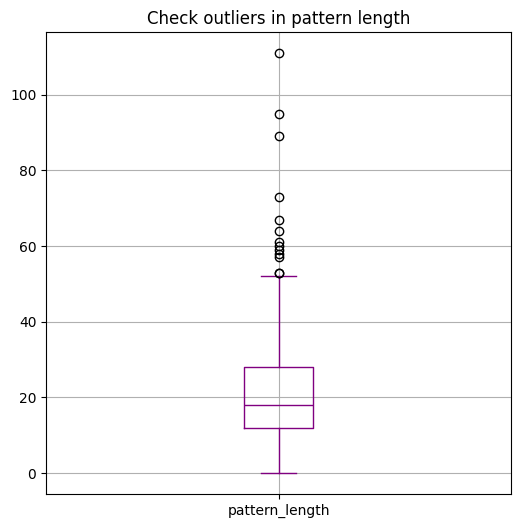

In [78]:
### outliers البحث عن  patternsفي 
df['pattern_length'] = df['patterns'].apply(lambda x: len(str(x)))


plt.figure(figsize=(6,6), facecolor='white')
df.boxplot(column='pattern_length', color='purple')
plt.title("Check outliers in pattern length")
plt.show()

In [79]:
#حذف ال outliers في patterns
q1 = df['pattern_length'].quantile(0.25)
q3 = df['pattern_length'].quantile(0.75)
IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

outliers = (df['pattern_length'] < lower_bound) | (df['pattern_length'] > upper_bound)

median_fare = df['pattern_length'].median()

df.loc[outliers, 'pattern_length'] = median_fare


<function matplotlib.pyplot.show(close=None, block=None)>

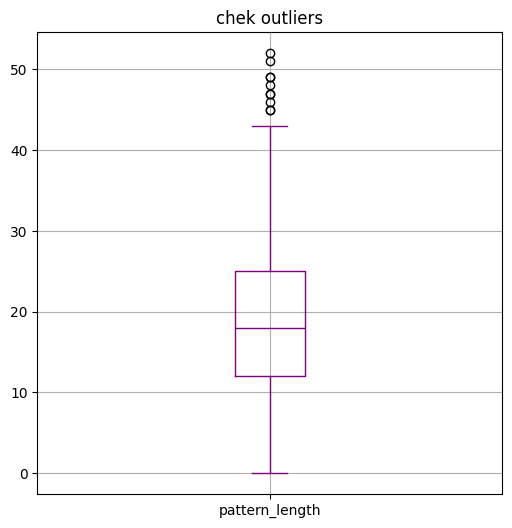

In [80]:
#التأكد من عدم وجود outliers في patterns
fig=plt.figure(figsize=(6,6),facecolor='white')
df.boxplot(color='purple')
plt.title("chek outliers")
plt.show

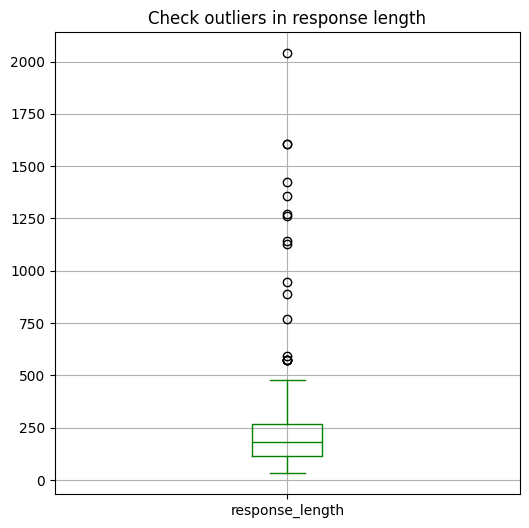

In [81]:
#التأكد من عدم وجود outliers في responses
df['response_length'] = df['responses'].apply(lambda x: len(str(x)))
plt.figure(figsize=(6,6), facecolor='white')
df.boxplot(column='response_length', color='green')
plt.title("Check outliers in response length")
plt.show()

In [82]:
#حذف ال outliers من responses
q1 = df['response_length'].quantile(0.25)
q3 = df['response_length'].quantile(0.75)
IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

outliers = (df['response_length'] < lower_bound) | (df['response_length'] > upper_bound)

median_fare = df['response_length'].median()

df.loc[outliers, 'response_length'] = median_fare


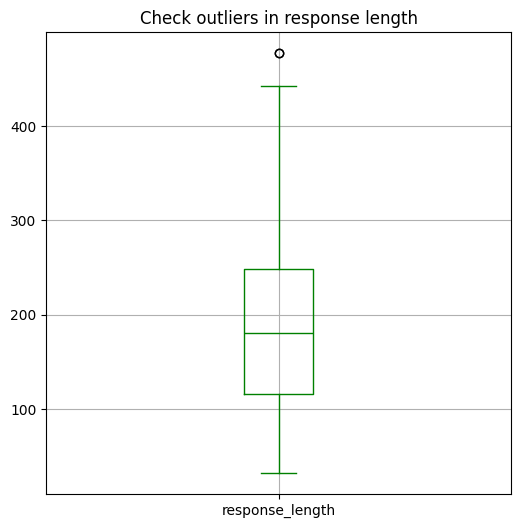

In [83]:
#التأكد من عدم وجود outliers في responses
plt.figure(figsize=(6,6), facecolor='white')
df.boxplot(column='response_length', color='green')
plt.title("Check outliers in response length")
plt.show()

In [84]:
#فحص بيانات الملف بالعدد الذي احدده للبيانات
df.head(25)

,tag,patterns,responses,pattern_length,response_length
0,greeting,Hi,[Hello there. Tell me how are you feeling toda...,2,262
1,greeting,Hey,[Hello there. Tell me how are you feeling toda...,3,262
2,greeting,Is anyone there?,[Hello there. Tell me how are you feeling toda...,16,262
3,greeting,Hi there,[Hello there. Tell me how are you feeling toda...,8,262
4,greeting,Hello,[Hello there. Tell me how are you feeling toda...,5,262
5,greeting,Hey there,[Hello there. Tell me how are you feeling toda...,9,262
6,greeting,Howdy,[Hello there. Tell me how are you feeling toda...,5,262
7,greeting,Hola,[Hello there. Tell me how are you feeling toda...,4,262
8,greeting,Bonjour,[Hello there. Tell me how are you feeling toda...,7,262
9,greeting,Konnichiwa,[Hello there. Tell me how are you feeling toda...,10,262


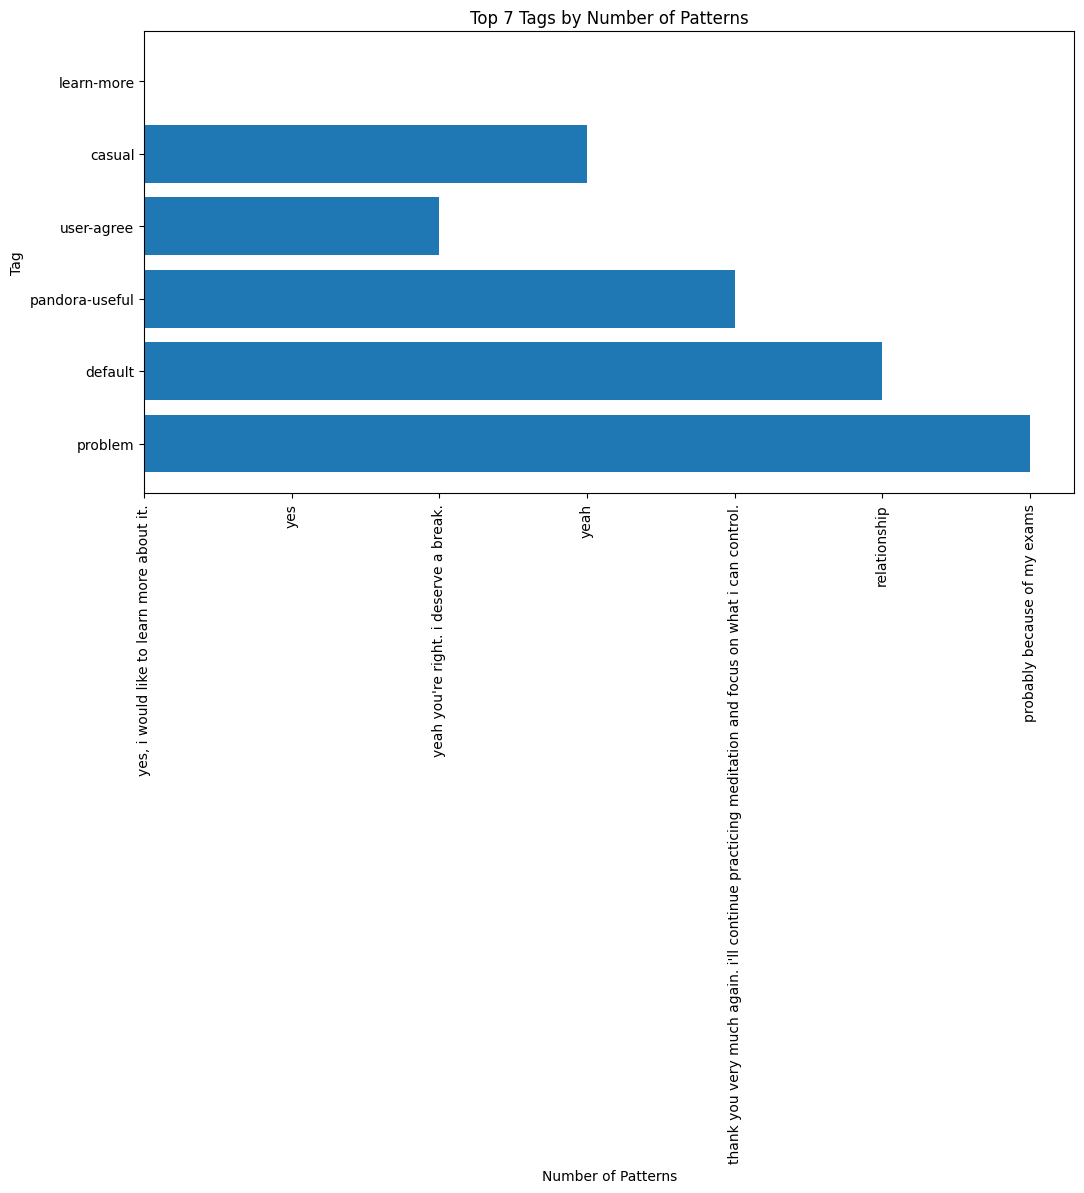

In [85]:
# إنشاء رسم بياني أفقي  يوضح أعلى 7 قيم في العمود patterns  ب مرتبطة tag
df_sorted = df.sort_values(by="patterns", ascending=False).head(7)
df["patterns_short"] = df["patterns"].str.slice(0,30)
plt.figure(figsize=(12,6))
plt.barh(df_sorted["tag"], df_sorted["patterns"])
plt.xlabel("Number of Patterns")
plt.ylabel("Tag")
plt.title("Top 7 Tags by Number of Patterns")
plt.gca().invert_yaxis()
plt.xticks(rotation=90) 
plt.show()

In [86]:
#تديد خصائص المدخلات وتحديد تصنيف المخرجات 
X = df["patterns"]     # المدخلات
y = df["responses"] #المخرجات

In [87]:
#( X & Y) عرض البيانات  

X.head()  

X.shape 

y.head() 

y.shape 

(232,)

In [88]:
#تقسيم البيانات الى 3 مجموعات تدريب و اختبار و تحقق 
x_train,x_temp,y_train,y_temp = train_test_split(X, y, test_size=0.2, random_state=42) 

x_val,x_test,y_val,y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42) 

In [89]:
#عرض البيانات بعد التقسيم 
print(x_train.shape) 

print(y_train.shape) 

print(x_test.shape) 

print(y_test.shape) 

print(x_val.shape) 

print(y_val.shape) 

(185,)
(185,)
(24,)
(24,)
(23,)
(23,)


In [90]:
#تنظيف النصوص في الأعمدة patterns و responses
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df["clean_pattern"] = df["patterns"].apply(clean_text)


In [91]:
#استدعاء نموذج تعلم عميق لتحويل النصوص الى اعداد متجهة ثم قياس التشابه في المعنى بعد المقارنة
model = SentenceTransformer("all-mpnet-base-v2")

corpus_embeddings = model.encode(
    df["clean_pattern"].tolist(),
    convert_to_tensor=True
)


Loading weights: 100%|██████████| 199/199 [00:01<00:00, 164.18it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [92]:
#إنشاء قاموس يربط كل tag مع قائمة الردود الخاصة به

tag_to_responses = {
    
    intent["tag"]: intent["responses"]
    for intent in json_data["intents"]
}

In [93]:
# بناء دالة chatbot 
def chatbot(user_input):
    user_input = clean_text(user_input)
    user_embedding = model.encode(user_input, convert_to_tensor=True)
    
    cosine_scores = util.cos_sim(user_embedding, corpus_embeddings)
    idx = int(cosine_scores.argmax())
    max_score = float(cosine_scores[0][idx])
    
    if max_score < 0.40:
        return "I didn't understand."
    
    predicted_tag = df["tag"].iloc[idx]
    return random.choice(tag_to_responses[predicted_tag])


In [94]:
#قياس دقة النموذج بالتشابه 
correct = 0

for i, row in df.iterrows():
    user_input = row["patterns"]
    true_tag = row["tag"]
    
    user_embedding = model.encode(clean_text(user_input), convert_to_tensor=True)
    cosine_scores = util.cos_sim(user_embedding, corpus_embeddings)
    idx = int(cosine_scores.argmax())
    predicted_tag = df["tag"].iloc[idx]
    
    if predicted_tag == true_tag:
        correct += 1

accuracy = correct / len(df)
print("Classification Accuracy:", accuracy)


Classification Accuracy: 0.9353448275862069


In [ ]:
#تنفيذ النموذج باستخدام واجهة GUI
def send_message():
    user_input = entry.get()
    if user_input.strip() == "":
        return

    if user_input.lower() in ["exit", "quit"]:
        chat_window.config(state='normal')
        chat_window.insert(tk.END, "Bot: Bye!\n", "bot")
        chat_window.config(state='disabled')
        root.destroy()
        return

    chat_window.config(state='normal')
    chat_window.insert(tk.END, f"You: {user_input}\n", "user")
    entry.delete(0, tk.END)

    bot_reply = chatbot(user_input)
    chat_window.insert(tk.END, f"Bot: {bot_reply}\n\n", "bot")
    chat_window.config(state='disabled')
    chat_window.yview(tk.END)

root = tk.Tk()
root.title("Chatbot")
root.geometry("700x500")
root.configure(bg="#3D6A70")

chat_window = scrolledtext.ScrolledText(
    root,
    width=70,
    height=20,
    wrap=tk.WORD,
    font=("Arial", 12),
    bg="#ECF0F1",
    fg="black"
)
chat_window.pack(padx=15, pady=15)
chat_window.config(state='normal')
chat_window.insert(tk.END, f"Bot is ready!\n", "bot")
chat_window.insert(tk.END, f"Type 'exit' or 'quit' to stop.\n\n", "bot")
chat_window.config(state='disabled')

chat_window.tag_config("user", foreground="#3D6A70")
chat_window.tag_config("bot", foreground="#000000")

bottom_frame = tk.Frame(root, bg="#FFFFFF")
bottom_frame.pack(pady=10)

entry = tk.Entry(bottom_frame, width=45, font=("Times New Roman", 10))
entry.pack(side=tk.LEFT, padx=10)

send_button = tk.Button(bottom_frame, text="Send", command=send_message,
                        font=("Arial", 11, "bold"), bg="#3498DB", fg="white", width=10)
send_button.pack(side=tk.LEFT)

root.mainloop()